# Full PID Analysis Pipeline

Load the **already-trained** ensemble (20 CTRNNs = 10 seeds x 2 tasks) and its saved
outputs, then compute the partial-information-decomposition (PID) analyses and figures
for the final presentation.

**Hypothesis.** The *context* task (integrate the cued stream, ignore the other) forces
the network to encode stimulus information **synergistically**, whereas the *perceptual*
task (accumulate a single stream) can be solved **redundantly**. This difference
should peak at the end of the stimulus period.

We *reuse* the analytic Gaussian MMI-PID in `src/analysis/gaussian_pid.py` (no
reimplementation): a GPU-batched wrapper below is validated to reproduce its numbers
to ~1e-10 bits while running ~40x faster.

## Imports
PyTorch (GPU-batched PID), NumPy, Matplotlib and SciPy (statistics). The existing
analytic PID lives in `src/analysis/gaussian_pid.py` and is imported only as the
reference implementation the GPU path is checked against.

In [24]:
import os, json, time               # paths, metrics JSON, timing
import numpy as np                  # arrays / IO
import pandas as pd                 # tidy long-form frames for the Fig-4 violins
import torch                        # GPU-batched PID (costliest step)
import matplotlib.pyplot as plt     # all figures
import seaborn as sns               # violin / strip plots (Fig 4)
from scipy import stats             # Mann-Whitney U control test

# Reference (CPU) implementation (used ONLY to validate the GPU path numerically).
from src.analysis.gaussian_pid import gaussian_pid_rnn
# GPU Gaussian PID implementation (used for all final figures).
from src.analysis.gaussian_pid import gaussian_pid_rnn_gpu

# Configuration for Mante et al. (2013) dataset generation (TIMING and DT)
from src.tasks.mante_config import TIMING, DT
# Trial timing in ms: TIMING = {"fixation": 300, "stimulus": 750, "delay": 0, "decision": 100}
# DT: ms per raw simulation step

import csv   # standard-library writer for the running stats_summary.csv

## Plotting conventions
Constants applied to **every** figure and computation: the two task colors, the fixed
5-atom PID set and its order, per-atom line colors, the single analysis seed, the task /
seed identifiers, the nats->bits factor, and the Matplotlib house style (no top/right
spines; fixed font sizes).

In [ ]:
# ---- Task colors (defined ONCE, reused everywhere) ----
COLOR_CONTEXT    = 'mediumturquoise'   # context task    (the "blue")
COLOR_PERCEPTUAL = 'tomato'            # perceptual task  (the "red")

# ---- PID atoms: ALWAYS all five, fixed order. total_mi = red + u1 + u2 + syn ----
ATOMS = ['total_mi', 'redundancy', 'unique1', 'unique2', 'synergy']

# Distinct colors so the five atoms are separable within one panel (legend labels them).
ATOM_COLORS = {
    'total_mi':   '#020202',   # black  (dotted) the Gaussian MMI total I(X1,X2;Y)
    'redundancy': '#4C78A8',   # blue
    'unique1':    "#F5A300",   # orange
    'unique2':    '#E618F5',   # purple 
    'synergy':    '#54A24B',   # red 
}

# ---- Reproducibility: one seed for bipartitions / random-neuron / kNN estimator ----
SEED_ANALYSIS = 0

# ---- Tasks & 1-based zero-padded seed ids CTRNN_01 to CTRNN_10 ----
TASKS    = ['perceptual', 'context']
N_SEEDS  = 10
SEED_IDS = [f"{i:02d}" for i in range(1, N_SEEDS + 1)]

# ---- Units: BITS everywhere. gaussian_pid returns bits when log_base=2; this factor
#      converts any nats quantity we might compute later (e.g. kNN MI). ----
NATS_TO_BITS = 1.0 / np.log(2.0)

# ---- Significance markers for ALL statistical tests (applied to every figure) ----
#   *  p < 0.05    **  p < 0.01    ***  p < 0.001    ****  p < 0.0001
#   n.s. (not significant) when p >= 0.05
def p_to_stars(p):
    """Map a p-value to its significance marker; 'n.s.' if p >= 0.05."""
    if   p < 1e-4: return '****'
    elif p < 1e-3: return '***'
    elif p < 1e-2: return '**'
    elif p < 5e-2: return '*'
    return 'n.s.'

# ---- Matplotlib house style (all figures) ----
plt.rcParams.update({
    'axes.spines.top':   False,   # remove top spine
    'axes.spines.right': False,   # remove right spine
    'xtick.labelsize': 16,        # axes tick/values = 16
    'ytick.labelsize': 16,
    'axes.labelsize':  18,        # axes labels = 18
    'legend.fontsize': 16,        # legend = 16
    'axes.titlesize':  20,        # subplot title = 20 (used only where a figure asks)
    'figure.titlesize':22,        # plot title = 22
})

# ---- Extra font sizes for the Figure 4 & 5 panels ----
# Matplotlib's rcParams only accepts its own keys, so the label types below (which the
# rcParams above do not cover, plus the per-figure tick / y-label sizes those two figures
# set explicitly) live here as plain constants. They sit in this same "Plotting
# conventions" cell so every Fig 4/5 panel can be retuned from one place, like the rcParams.
FS_TICK          = 16   # tick labels in the Fig 4 & 5 panels (override the rcParams default)
FS_SIG_MARKER    = 16   # significance-bracket marker text (*, **, ***, ****, n.s.)
FS_BAR_VALUE     = 14   # mean value printed at each bar in the bar panels
FS_YLABEL_VIOLIN = 18   # y-axis label in the Fig 4b decision-time violins
FS_YLABEL_GRID   = 18   # y-axis label in the Fig 5 2x3 panels

## Input / output paths & device
Where the saved metrics, activations and PID-target coherences live, and where figures
and PID caches are written. Also select CUDA if available (the PID is the costliest
step and runs on the GPU).

In [26]:
# --- input directories (paths relative to notebooks/) ---
RES_METRICS_DIR = "../results/accuracies_n_losses"   # scalar loss/acc per CTRNN (JSON)
RES_ACTS_DIR    = "../results/model_activations"     # hidden acts [n_trials, T, n_hidden]
RES_COH_DIR     = "../results/stimulus_coherences"   # PID target: signed cued/attended coherence

# --- output directories ---
PID_OUT_DIR = "../results/pid_outputs"               # cached PID arrays
STATS_OUT_DIR = "../figures"                         # CSV of all statistical tests
FIG_ACC_DIR = "../figures/accuracy_loss"             # Figure 1
FIG_PID_DIR = "../figures/all_time_pid"              # Figure 2 (one PNG per seed)
for d in [FIG_ACC_DIR, FIG_PID_DIR,
          os.path.join(PID_OUT_DIR, 'context'),
          os.path.join(PID_OUT_DIR, 'perceptual')]:
    os.makedirs(d, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Compute device:", device,
      "-", torch.cuda.get_device_name(0) if device.type == "cuda" else "CPU")

# --- Statistics summary accumulator ---
# Every statistical test in the notebook (MWU, Shapiro-Wilk, ...) appends a row here,
# keyed by a unique test id so re-running a cell overwrites its own rows (never dups)
# and no stats variable is ever reused between tests. Written to CSV once, at the end.
stats_summary_records = {}

Compute device: cuda - NVIDIA GeForce GTX 1050


## Trial timing & shared decision time
Mirror `src/tasks/mante_config.py`. The saved activations use `SUBSAMPLE_STEP=1`
(notebook 05), so one saved timestep equals `DT = 10 ms`. `DECISION_T` is derived (not
hardcoded) as the **last timestep of the stimulus period** (end of fixation+stimulus);
the same `DECISION_T` is reused by every later decision-time slice.

In [27]:
# Trial timing in ms (identical to src/tasks/mante_config.py)
SUBSAMPLE_STEP = 1                             # notebook 05 saved acts unsubsampled
MS_PER_STEP = DT * SUBSAMPLE_STEP              # -> 10 ms per saved timestep
TOTAL_TIMESTEPS = sum(TIMING.values()) // DT   # 1150/10 = 115  (matches acts' T axis)

# Stimulus period occupies steps [fixation, fixation+stimulus); STIM_START is its first
# step, DECISION_T its last step (the moment of decision we slice at everywhere).
STIM_START_STEP = TIMING["fixation"] // DT                            # 30
DECISION_T      = (TIMING["fixation"] + TIMING["stimulus"]) // DT - 1  # 104

def steps_to_ms(t):
    """Map a saved timestep index (or array of them) to time in ms."""
    return np.asarray(t) * MS_PER_STEP

print(f"T = {TOTAL_TIMESTEPS} steps @ {MS_PER_STEP} ms/step | "
      f"stimulus steps {STIM_START_STEP}..{DECISION_T} | "
      f"DECISION_T = {DECISION_T} ({DECISION_T*MS_PER_STEP} ms)")

T = 115 steps @ 10 ms/step | stimulus steps 30..104 | DECISION_T = 104 (1040 ms)


## Data loading
Thin loaders for the three saved artifacts, keyed by task and 1-based padded seed id.
The PID **target** is the signed, noiseless scalar coherence already reduced to the
relevant stream on disk: the cued modality for *context*, the single attended stream for
*perceptual*. It is continuous (values in [-18.75, +18.75]).

In [28]:
def load_metrics(task, seed_id):
    """Scalar train/val/test loss & accuracy for one CTRNN (dict)."""
    with open(f"{RES_METRICS_DIR}/{task}/CTRNN_{seed_id}.json") as f:
        return json.load(f)

def load_activations(task, seed_id):
    """Hidden activations for one CTRNN's test set: [n_trials, T, n_hidden]."""
    return np.load(f"{RES_ACTS_DIR}/{task}/CTRNN_{seed_id}.npy")

def load_coherences(task, seed_id):
    """PID target = signed coherence (cued/attended), shape (n_trials,)."""
    z = np.load(f"{RES_COH_DIR}/{task}/test_{seed_id}_coherences.npz")
    return z['arr_0'].astype(float)     # single stored array; already the right stream

# quick shape sanity check on one file per task
for t in TASKS:
    H, Y = load_activations(t, '01'), load_coherences(t, '01')
    print(f"{t:11s}  acts {H.shape}  target {Y.shape}  "
          f"target range [{Y.min():.2f}, {Y.max():.2f}]")

perceptual   acts (2000, 115, 100)  target (2000,)  target range [-18.75, 18.75]
context      acts (2000, 115, 100)  target (2000,)  target range [-18.75, 18.75]


## Figure 1: Test accuracy & loss bars
Two stacked bar subplots sharing x = seed (1-10): test **accuracy** (top) and test
**loss** (bottom), context vs perceptual grouped side-by-side per seed. Then a
Mann-Whitney U test on `test_acc` (context vs perceptual): we **expect non-significance**. This is the control showing later PID differences are not a mere accuracy artifact.

Gather scalar metrics: Read every CTRNN's `test_acc` / `test_loss` into per-task arrays indexed by seed.

In [29]:
# per-task arrays over the 10 seeds
test_acc  = {t: np.array([load_metrics(t, s)['test_acc']  for s in SEED_IDS]) for t in TASKS}
test_loss = {t: np.array([load_metrics(t, s)['test_loss'] for s in SEED_IDS]) for t in TASKS}
for t in TASKS:
    print(f"{t:11s}  acc {test_acc[t].mean():.3f}+/-{test_acc[t].std():.3f}   "
          f"loss {test_loss[t].mean():.3f}+/-{test_loss[t].std():.3f}")

perceptual   acc 0.887+/-0.005   loss 0.256+/-0.008
context      acc 0.885+/-0.005   loss 0.261+/-0.009


#### 1a. Accuracy-matched control (Mann-Whitney U) 
Non-parametric test of `test_acc` across the two task groups (n=10 each). A
**non-significant** result (p > 0.05) means the two ensembles are accuracy-matched, so
any PID difference cannot be explained by one task simply being solved better.

In [30]:
u_stat, p_acc = stats.mannwhitneyu(test_acc['context'], test_acc['perceptual'],
                                   alternative='two-sided')
print(f"MWU on test_acc (context vs perceptual): U = {u_stat:.1f}, p = {p_acc:.7f}")
print("=> NON-significant at alpha=0.05: accuracy matched, PID differences are not a "
      "performance artifact." if p_acc > 0.05 else
      "=> SIGNIFICANT (unexpected): accuracies differ across tasks.")

u_stat_loss, p_loss = stats.mannwhitneyu(test_loss['context'], test_loss['perceptual'],
                                         alternative='two-sided')
print(f"MWU on test_loss (context vs perceptual): U = {u_stat_loss:.1f}, p = {p_loss:.7f}")
print("=> NON-significant at alpha=0.05: losses matched." if p_loss > 0.05 else
      "=> SIGNIFICANT (unexpected): losses differ across tasks.")

# --- record both MWU results into the running stats_summary.csv (unique keys: never
#     reuse/overwrite another test's row) ---
stats_summary_records['mwu_test_acc'] = {
    'test': 'Mann-Whitney U (context vs perceptual)',
    'metric': 'test_acc',
    'n': N_SEEDS,
    'statistic': float(u_stat),
    'p_value': float(p_acc),
    'significant': bool(p_acc < 0.05),
}
stats_summary_records['mwu_test_loss'] = {
    'test': 'Mann-Whitney U (context vs perceptual)',
    'metric': 'test_loss',
    'n': N_SEEDS,
    'statistic': float(u_stat_loss),
    'p_value': float(p_loss),
    'significant': bool(p_loss < 0.05),
}

MWU on test_acc (context vs perceptual): U = 40.0, p = 0.4726756
=> NON-significant at alpha=0.05: accuracy matched, PID differences are not a performance artifact.
MWU on test_loss (context vs perceptual): U = 71.0, p = 0.1212245
=> NON-significant at alpha=0.05: losses matched.


#### 1b. Plot the bars
Grouped bars per seed, task colors, labeled legend, no titles. Saved to
`figures/accuracy_loss/test_accuracy_loss_bars.png` and shown inline.

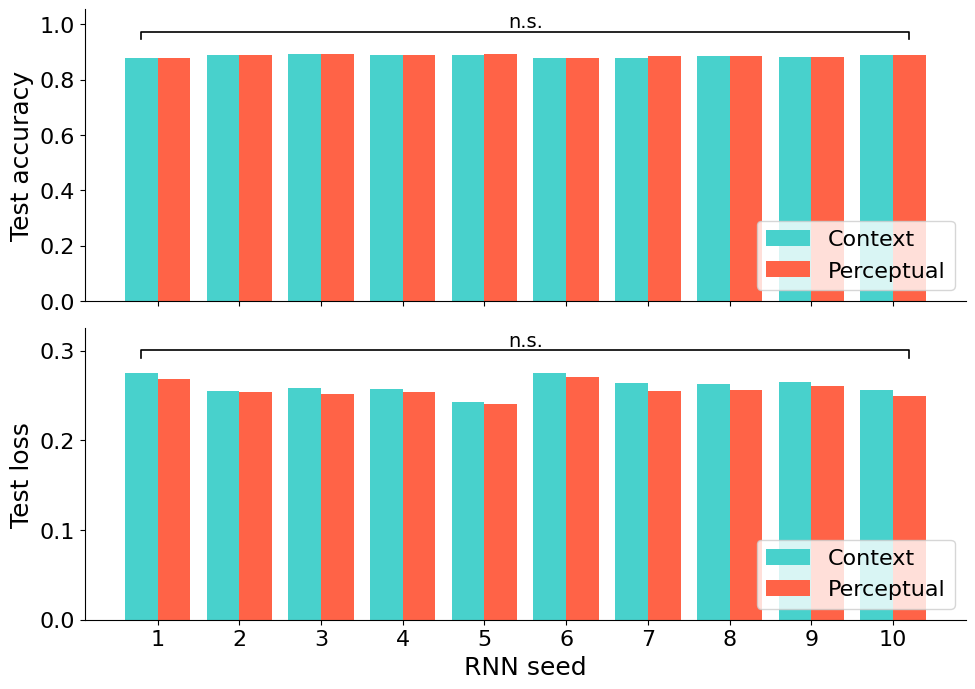

In [31]:
seeds = np.arange(1, N_SEEDS + 1)     # x positions = seed number 1..10
w = 0.4                                # bar width (two grouped bars per seed)

def annotate_sig(ax, x1, x2, p, data_top):
    """Horizontal significance bracket x1..x2 above the bars, marker via p_to_stars(p)."""
    span = data_top - ax.get_ylim()[0]
    y, h = data_top + 0.06*span, 0.03*span
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, color='black')
    ax.text((x1+x2)/2, y+h, p_to_stars(p), ha='center', va='bottom', fontsize=14)
    ax.set_ylim(top=y + 4*h)   # headroom so bracket + marker are not clipped

fig, (ax_acc, ax_loss) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# --- top: test accuracy (context left bar, perceptual right bar) ---
ax_acc.bar(seeds - w/2, test_acc['context'],    w, color=COLOR_CONTEXT,    label='Context')
ax_acc.bar(seeds + w/2, test_acc['perceptual'], w, color=COLOR_PERCEPTUAL, label='Perceptual')
ax_acc.set_ylabel('Test accuracy')
ax_acc.legend(loc='lower right')

# --- bottom: test loss (same coloring) ---
ax_loss.bar(seeds - w/2, test_loss['context'],    w, color=COLOR_CONTEXT,    label='Context')
ax_loss.bar(seeds + w/2, test_loss['perceptual'], w, color=COLOR_PERCEPTUAL, label='Perceptual')
ax_loss.set_ylabel('Test loss')
ax_loss.set_xlabel('RNN seed')
ax_loss.set_xticks(seeds)
ax_loss.legend(loc='lower right')

# --- significance bracket (MWU context vs perceptual) on top of each panel ---
xl, xr = seeds[0] - w/2, seeds[-1] + w/2
annotate_sig(ax_acc,  xl, xr, p_acc,  max(test_acc['context'].max(),  test_acc['perceptual'].max()))
annotate_sig(ax_loss, xl, xr, p_loss, max(test_loss['context'].max(), test_loss['perceptual'].max()))

fig.tight_layout()
fig.savefig(f"{FIG_ACC_DIR}/test_accuracy_loss_bars.png", dpi=300)
plt.show()


## Figure 2: Time-resolved PID for all seeds
Compute the Gaussian MMI-PID at **every timestep** for all 10 CTRNNs of each task,
bipartition-averaged over 200 random 50/50 unit splits (same procedure as the existing
`gaussian_pid_rnn`). Cache to `all_time_PID_{context,perceptual}` shaped
`[n_seeds=10, T, n_atoms=5]` in bits (atom axis = `ATOMS`), persist to disk, then draw
one figure per seed (perceptual | context).

#### 2a. GPU-batched PID (validated against `gaussian_pid_rnn`)
The bottleneck in `gaussian_pid_rnn` is recomputing a fresh covariance for each of the
200 bipartitions at each of 115 timesteps. But at a given timestep the joint covariance
over *all* units + target is shared across bipartitions, so we compute it **once per
timestep** on the GPU and only batch the small sub-block log-determinants per split. The
bipartition sequence is generated with the *same* regularization as `gaussian_pid_rnn`, so results
match to ~1e-10 bits (checked in 2b).

#### 2b. Sanity check vs the reference implementation
Run one seed through both paths on a handful of timesteps and confirm the GPU result
matches `gaussian_pid_rnn` to within numerical noise (< 1e-6 bits). This justifies using
the fast path for all 20 CTRNNs. Uncomment only if you want to re-run the check; it takes 1-3 min and not needed for normal operation.

In [32]:
# # ----- Uncomment only to validate again -----
# _H = load_activations('context', '01'); _Y = load_coherences('context', '01')
# _gpu = gaussian_pid_rnn_gpu(_H, _Y, n_bip=200, seed=SEED_ANALYSIS, reg=1e-5)
# _ref = gaussian_pid_rnn(activations=_H, target=_Y, timestep=None, bipartitions='random',
#                         n_bipartitions=200, seed=SEED_ANALYSIS, log_base=2, regularization=1e-5)
# _ref_arr = np.stack([_ref['redundancy'] + _ref['unique1'] + _ref['unique2'] + _ref['synergy'],
#                      _ref['redundancy'], _ref['unique1'], _ref['unique2'], _ref['synergy']], axis=1)
# print(f"max |GPU - reference| over all timesteps/atoms = {np.abs(_gpu - _ref_arr).max():.2e} bits")
# assert np.abs(_gpu - _ref_arr).max() < 1e-6, "GPU PID diverges from reference!"
# print("OK - GPU PID reproduces gaussian_pid_rnn.")
# # ----- Uncomment only to validate again -----

#### 2c. Compute (or load) the cached PID arrays
For each task, run the time-resolved PID over all 10 seeds into
`all_time_PID_{task}` of shape `[n_seeds, T, 5]` (bits, atom order = `ATOMS`). If the
`.npy` caches already exist they are loaded instead of recomputed. Each array is
persisted with a JSON **sidecar** documenting axis meaning, atom order and units.

In [33]:
def compute_all_time_pid(task):
    """Time-resolved PID for all seeds of a task -> (n_seeds, T, 5) in bits."""
    out = np.zeros((N_SEEDS, TOTAL_TIMESTEPS, len(ATOMS)))
    for i, s in enumerate(SEED_IDS):
        H, Y = load_activations(task, s), load_coherences(task, s)
        out[i] = gaussian_pid_rnn_gpu(H, Y, n_bip=200, seed=SEED_ANALYSIS, reg=1e-5)
        print(f"  {task:11s} CTRNN_{s}  synergy@DECISION_T = {out[i, DECISION_T, 4]:.4f} bits")
    return out

def save_pid(arr, task):
    """Persist the array + a JSON sidecar describing its axes/atoms/units."""
    np.save(f"{PID_OUT_DIR}/{task}/all_time_PID.npy", arr)
    meta = {
        "array_file": "all_time_PID.npy",
        "shape": list(arr.shape),
        "axes": ["seed 0..9 = CTRNN_01..CTRNN_10",
                 f"timestep 0..{TOTAL_TIMESTEPS-1} ({MS_PER_STEP} ms each)",
                 "atom"],
        "atom_order": ATOMS,
        "units": "bits",
        "decision_t": DECISION_T,
        "note": ("Gaussian MMI-PID, bipartition-averaged over 200 random 50/50 unit "
                 "splits (seed=%d). total_mi = redundancy+unique1+unique2+synergy." % SEED_ANALYSIS),
    }
    with open(f"{PID_OUT_DIR}/{task}/all_time_PID_meta.json", "w") as f:
        json.dump(meta, f, indent=2)

ctx_path = f"{PID_OUT_DIR}/context/all_time_PID.npy"
per_path = f"{PID_OUT_DIR}/perceptual/all_time_PID.npy"
if os.path.exists(ctx_path) and os.path.exists(per_path):
    all_time_PID_context    = np.load(ctx_path)      # cached: skip recomputation
    all_time_PID_perceptual = np.load(per_path)
    print("Loaded cached PID arrays:", all_time_PID_context.shape, all_time_PID_perceptual.shape)
else:
    t0 = time.time()
    print("Computing perceptual...");  all_time_PID_perceptual = compute_all_time_pid('perceptual')
    print("Computing context...");     all_time_PID_context    = compute_all_time_pid('context')
    save_pid(all_time_PID_perceptual, 'perceptual')
    save_pid(all_time_PID_context,    'context')
    print(f"Done in {time.time()-t0:.1f}s. Saved arrays + sidecars to {PID_OUT_DIR}/")

Loaded cached PID arrays: (10, 115, 5) (10, 115, 5)


#### 2d. Per-seed time-resolved PID figures
One figure per seed: **left = perceptual**, **right = context**, sharing the y-axis. All
five atoms are drawn with their distinct `ATOM_COLORS` and a labeled legend; the panel's
**task color** tints the stimulus-period shading and the axis spines so the two tasks are
identifiable without titles. Following `plot_pid_ax`, a dashed red line marks the decision
time and the stimulus window is shaded. x = Time (ms), y = Information (bits). The 20
figures are saved (not shown).

In [34]:
def plot_pid_ax(ax, pid, task_color, task_name):
    """Draw the 5 PID atoms (bits) over time (ms) on one axis, notebook-06 style."""
    t_ms = steps_to_ms(np.arange(TOTAL_TIMESTEPS))
    # atom curves: synergy & redundancy emphasized (lw=3), uniques thinner, total dotted
    ax.plot(t_ms, pid[:, 1], color=ATOM_COLORS['redundancy'], lw=3.0, label='Redundancy')
    ax.plot(t_ms, pid[:, 4], color=ATOM_COLORS['synergy'],    lw=3.0, label='Synergy')
    ax.plot(t_ms, pid[:, 2], color=ATOM_COLORS['unique1'], lw=1.5, label='Unique 1')
    ax.plot(t_ms, pid[:, 3], color=ATOM_COLORS['unique2'], lw=1.5, label='Unique 2')
    ax.plot(t_ms, pid[:, 0], color=ATOM_COLORS['total_mi'], lw=1.5, ls=':', label='Total MI')
    # decision-time marker + stimulus-period shading (tinted with the task color)
    ax.axvline(DECISION_T * MS_PER_STEP, color='red', ls='--', label='Decision time')
    ax.axvspan(STIM_START_STEP * MS_PER_STEP, DECISION_T * MS_PER_STEP,
               color=task_color, alpha=0.12)
    # task-colored spines to identify the panel's task without a title
    for side in ('left', 'bottom'):
        ax.spines[side].set_linewidth(2.0)
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Information (bits)')

    # subplot title = task name + seed id (e.g. "Perceptual CTRNN_01")
    ax.set_title(f"{task_name.title()} (CTRNN_{SEED_IDS[i]})")

for i, s in enumerate(SEED_IDS):
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    plot_pid_ax(axL, all_time_PID_perceptual[i], COLOR_PERCEPTUAL, TASKS[0])   # left = perceptual
    plot_pid_ax(axR, all_time_PID_context[i],    COLOR_CONTEXT, TASKS[1])      # right = context
    axL.legend(loc='upper left')
    fig.tight_layout()
    fig.savefig(f"{FIG_PID_DIR}/CTRNN_{s}.png", dpi=300)
    plt.close(fig)                                                   # 20 figures -> don't show
print(f"Saved {N_SEEDS} per-seed PID figures to {FIG_PID_DIR}/")

Saved 10 per-seed PID figures to ../figures/all_time_pid/


## Figure 3: Mean +/- SD time-resolved PID (across seeds)
Collapse the 10 per-seed PID curves (in Fig 2, **not recomputed**) into a single
mean +/- SD trace per task. For each task we average every PID atom across the 10 CTRNNs
(mean = solid line) and shade +/-1 SD across seeds (band). All five atoms (incl.
`total_mi`) are drawn in their `ATOM_COLORS` with a labeled legend; the task color tints
the stimulus shading. Laid out as two shared-y subplots (perceptual | context), each
titled with its task name as in Fig 2.

- Save: `figures/mean_all_time_pid/mean_all_time_pid.png`

#### 3a. Aggregate the cached per-seed PID (mean & SD across the 10 seeds)
Reduce the cached `all_time_PID_{task}` `[n_seeds, T, 5]` (from Fig 2) along the seed
axis into per-task **mean** and **SD** `[T, 5]` arrays. SD uses `ddof=1` (sample SD of
the 10 seeds). No PID is recomputed here.

In [35]:
# Aggregate the cached per-seed PID (from Fig 2) across the 10 seeds. NO PID recompute:
# we only take mean/SD of the already-cached [n_seeds, T, 5] arrays along the seed axis.
mean_time_PID = {
    'perceptual': all_time_PID_perceptual.mean(axis=0),        # (T, 5) mean over seeds
    'context':    all_time_PID_context.mean(axis=0),
}
# SD across seeds with ddof=1 (sample SD of the 10 seeds) -> the band is the unbiased
# estimate of per-atom spread across networks.
sd_time_PID = {
    'perceptual': all_time_PID_perceptual.std(axis=0, ddof=1),  # (T, 5) SD over seeds
    'context':    all_time_PID_context.std(axis=0, ddof=1),
}

# output dir for the single (two-panel) mean-PID figure
FIG_MEAN_PID_DIR = "../figures/mean_all_time_pid"
os.makedirs(FIG_MEAN_PID_DIR, exist_ok=True)

# quick check: mean +/- SD of synergy at decision time per task (bits)
for t in TASKS:
    m = mean_time_PID[t][DECISION_T, 4]                          # atom idx 4 = synergy
    s = sd_time_PID[t][DECISION_T, 4]
    print(f"{t:11s} synergy@DECISION_T = {m:.4f} +/- {s:.4f} bits (mean +/- SD over {N_SEEDS} seeds)")

perceptual  synergy@DECISION_T = 0.0066 +/- 0.0009 bits (mean +/- SD over 10 seeds)
context     synergy@DECISION_T = 0.0178 +/- 0.0029 bits (mean +/- SD over 10 seeds)


#### 3b. Draw & save the mean +/- SD figure
A single figure with two shared-y subplots (**left = perceptual**, **right = context**),
each titled with its task name as in Fig 2: the five mean atom curves with +/-1 SD bands,
a task-tinted stimulus shading + decision line, and a labeled legend. x = Time (ms),
y = Information (bits). Saved as PNG (dpi=300) to `figures/mean_all_time_pid/`.

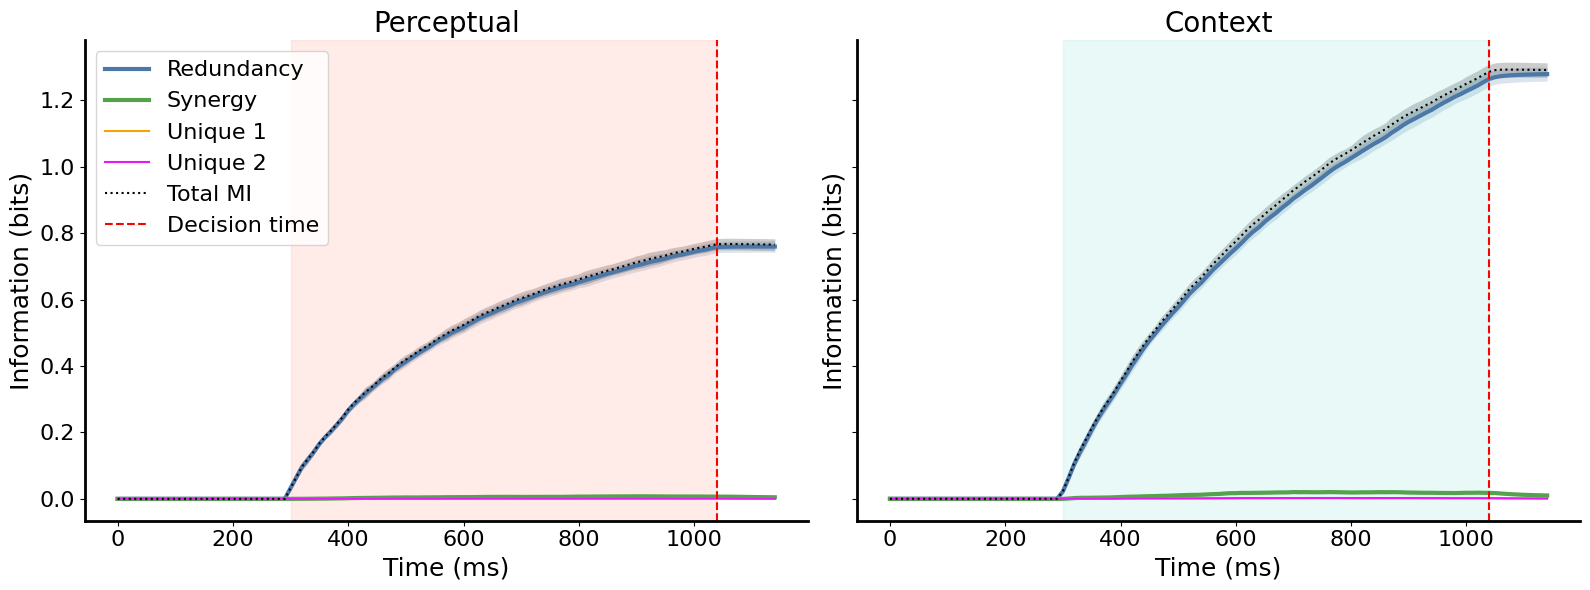

Saved mean +/- SD PID figure to ../figures/mean_all_time_pid/mean_all_time_pid.png


In [36]:
def plot_mean_sd_pid_ax(ax, mean_pid, sd_pid, task_color, task_name):
    """Mean (line) +/- SD (band) of the 5 PID atoms over time (ms), notebook-06 style.

    Atoms keep their distinct ATOM_COLORS (so the labeled legend separates them); the
    task color tints the stimulus shading and the panel is titled with its task name as
    in Fig 2. total_mi stays dotted per the global 'Plotting conventions'.
    """
    t_ms = steps_to_ms(np.arange(TOTAL_TIMESTEPS))          # x axis in ms
    # (atom name, atom-axis index, linewidth, alpha, linestyle, legend label)
    specs = [
        ('redundancy', 1, 3.0, 1.0, '-', 'Redundancy'),    # emphasized (lw=3)
        ('synergy',    4, 3.0, 1.0, '-', 'Synergy'),        # emphasized (lw=3)
        ('unique1',    2, 1.5, 1.0, '-', 'Unique 1'),
        ('unique2',    3, 1.5, 1.0, '-', 'Unique 2'),
        ('total_mi',   0, 1.5, 1.0, ':', 'Total MI'),       # dotted (global convention)
    ]
    for name, j, lw, a, ls, lab in specs:
        c = ATOM_COLORS[name]
        # mean across seeds as a solid (total_mi: dotted) line
        ax.plot(t_ms, mean_pid[:, j], color=c, lw=lw, alpha=a, ls=ls, label=lab)
        # +/-1 SD across seeds as a translucent shaded band in the same atom color
        ax.fill_between(t_ms, mean_pid[:, j] - sd_pid[:, j], mean_pid[:, j] + sd_pid[:, j],
                        color=c, alpha=0.20, linewidth=0)
    # decision-time marker + stimulus-period shading (tinted with the task color)
    ax.axvline(DECISION_T * MS_PER_STEP, color='red', ls='--', label='Decision time')
    ax.axvspan(STIM_START_STEP * MS_PER_STEP, DECISION_T * MS_PER_STEP,
               color=task_color, alpha=0.12)
    for side in ('left', 'bottom'):
        ax.spines[side].set_linewidth(2.0)
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Information (bits)')
    ax.set_title(task_name.title())                        # subplot title = task name

# single figure: left = perceptual, right = context, shared y-axis (as in Fig 2)
fig, (axL, axR) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
plot_mean_sd_pid_ax(axL, mean_time_PID['perceptual'], sd_time_PID['perceptual'],
                    COLOR_PERCEPTUAL, TASKS[0])            # left = perceptual
plot_mean_sd_pid_ax(axR, mean_time_PID['context'],    sd_time_PID['context'],
                    COLOR_CONTEXT, TASKS[1])               # right = context
axL.legend(loc='upper left')                               # labeled legend for the 5 atoms
fig.tight_layout()
fig.savefig(f"{FIG_MEAN_PID_DIR}/mean_all_time_pid.png", dpi=300)
plt.show()
print(f"Saved mean +/- SD PID figure to {FIG_MEAN_PID_DIR}/mean_all_time_pid.png")

#### 3c. Normality (Shapiro-Wilk) at decision time
For each of the 5 atoms x 2 tasks, test whether the **per-seed** values at `DECISION_T`
(n = 10) are normally distributed. Shapiro-Wilk is the correct, higher-power choice for
small n with unknown (not known-in-advance) parameters.

**Multiple comparisons.** `total_mi` is the deterministic sum of the other four atoms, so
it is not an independent hypothesis: it is still tested but excluded from the correction
family (scored uncorrected). The family is therefore the 4 independent atoms x 2 tasks =
8 tests. We Bonferroni-correct the **p-values** (x8) -- never the threshold -- then decide
significance with the global `p_to_stars` criteria on the corrected p. The factor is the
*number of tests in the family*, not the sample size: n = 10 sets each test's power, the
8 tests set the correction.

**Caveat.** At n = 10 every normality test is underpowered, so a non-significant SW
result is only weak evidence of normality.

Results (statistic, uncorrected p, Bonferroni-corrected p, pass/fail) are appended to the
running `figures/stats_summary.csv`.

In [37]:
# --- Bonferroni family: 4 INDEPENDENT atoms x 2 tasks = 8 normality tests ---------
# total_mi = redundancy + unique1 + unique2 + synergy is the DETERMINISTIC sum of the
# other four atoms, so it is NOT an independent hypothesis and is excluded from the
# correction family; it is still tested but scored uncorrected (k=1). The correction
# factor is the number of INDEPENDENT tests: 4 atoms x 2 tasks = 8.
SW_COMPARISON_ATOMS = ['redundancy', 'unique1', 'unique2', 'synergy']   # exclude total_mi
N_SW_TESTS = len(SW_COMPARISON_ATOMS) * len(TASKS)   # 8 = Bonferroni factor for the p-values

# Persistent accumulator for results/pid_outputs/stats_summary.csv, built across the
# whole notebook. Keyed by a unique test id so re-running a cell overwrites (never dups)
# and no stats variable is ever reused between tests.
if 'stats_summary_records' not in globals():
    stats_summary_records = {}

# Decision-time per-seed atom values, sliced from the cached Fig-2 arrays (NO recompute).
decision_pid = {
    'perceptual': all_time_PID_perceptual[:, DECISION_T, :],   # (n_seeds=10, 5)
    'context':    all_time_PID_context[:, DECISION_T, :],
}

print(f"Shapiro-Wilk normality at DECISION_T (n={N_SEEDS} seeds), "
      f"Bonferroni x{N_SW_TESTS} on the p-values\n")
for task in TASKS:
    for j, atom in enumerate(ATOMS):                      # all 5 atoms incl. total_mi
        vals_sw = decision_pid[task][:, j]               # (10,) per-seed values @ DECISION_T
        sw_stat, sw_p = stats.shapiro(vals_sw)           # SW: high-power for small n
        # total_mi is excluded from the correction family (dependent quantity) -> scored
        # uncorrected (k=1); the 4 independent atoms are corrected by k=8. Only the
        # P-VALUE is corrected (never the threshold): significance follows the global
        # p_to_stars rules on the corrected p (normal = p_to_stars -> 'n.s.').
        sw_bonf_k = 1 if atom == 'total_mi' else N_SW_TESTS
        sw_p_bonf = min(sw_p * sw_bonf_k, 1.0)           # Bonferroni-corrected p (capped at 1)
        sw_pass = p_to_stars(sw_p_bonf) == 'n.s.'        # fail to reject -> "normal"
        # unique key per (test, task, atom) -> no stats variable is ever overwritten
        stats_summary_records[f"shapiro_{task}_{atom}"] = {
            'test': 'Shapiro-Wilk normality',
            'task': task,
            'atom': atom,
            'n': int(len(vals_sw)),
            'statistic': float(sw_stat),
            'p_value': float(sw_p),
            'p_value_bonferroni': float(sw_p_bonf),
            'bonferroni_factor': sw_bonf_k,
            'pass_normality': bool(sw_pass),
        }
        print(f"  {task:11s} {atom:10s}  W={sw_stat:.3f}  p={sw_p:.7f}  p_bonf={sw_p_bonf:.7f}  "
              f"-> {'normal (fail to reject)' if sw_pass else 'NON-normal (reject)'}")

# --- write the accumulated stats out to the running CSV --------------------------
# base column order first, then any extra columns future tests may add (robust union).
_base_cols = ['test', 'task', 'atom', 'n', 'statistic', 'p_value',
              'bonferroni_factor', 'pass_normality']
_extra = sorted({k for r in stats_summary_records.values() for k in r} - set(_base_cols))
csv_path = f"{STATS_OUT_DIR}/stats_summary.csv"
with open(csv_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=_base_cols + _extra)
    writer.writeheader()
    for key in sorted(stats_summary_records):            # deterministic row order
        writer.writerow(stats_summary_records[key])
print(f"\nWrote {len(stats_summary_records)} stat rows to {csv_path}")
print("Caveat: at n=10 all normality tests are underpowered, so a non-significant SW "
      "result is only weak evidence of normality.")

Shapiro-Wilk normality at DECISION_T (n=10 seeds), Bonferroni x8 on the p-values

  perceptual  total_mi    W=0.820  p=0.0250793  p_bonf=0.0250793  -> NON-normal (reject)
  perceptual  redundancy  W=0.818  p=0.0236974  p_bonf=0.1895794  -> normal (fail to reject)
  perceptual  unique1     W=0.906  p=0.2548725  p_bonf=1.0000000  -> normal (fail to reject)
  perceptual  unique2     W=0.823  p=0.0274056  p_bonf=0.2192447  -> normal (fail to reject)
  perceptual  synergy     W=0.859  p=0.0738895  p_bonf=0.5911163  -> normal (fail to reject)
  context     total_mi    W=0.948  p=0.6434603  p_bonf=0.6434603  -> normal (fail to reject)
  context     redundancy  W=0.926  p=0.4112810  p_bonf=1.0000000  -> normal (fail to reject)
  context     unique1     W=0.801  p=0.0148828  p_bonf=0.1190621  -> normal (fail to reject)
  context     unique2     W=0.897  p=0.2009801  p_bonf=1.0000000  -> normal (fail to reject)
  context     synergy     W=0.947  p=0.6294466  p_bonf=1.0000000  -> normal (fail to 

## Figure 4: Decision-time PID (context vs perceptual)
At `DECISION_T` each atom has 10 per-seed values per task. We compare the two tasks
**per atom** with a two-sided Mann-Whitney U test whose p-values are Bonferroni-corrected
(x4 across the 4 atoms), then show the distributions two ways: per-atom **violins**
(individual seeds overlaid, a bold cross-bar at the median) and, as a quick-read variant,
grouped **mean +/- SD bars**. `total_mi` is included as one of the five atoms. Nothing is
recomputed: we reuse the cached decision-time per-seed values (`decision_pid`, Fig 3c) and
the Fig-3 across-seed mean/SD (`mean_time_PID`/`sd_time_PID`).

#### 4a. Per-atom Mann-Whitney U (context vs perceptual) at decision time
Build `decision_atoms[task][atom]` (10 per-seed values) by slicing the cached
decision-time array, then run one two-sided MWU per atom (n=10 vs 10). Family = 4 atoms,
so we **Bonferroni-correct the p-values** (x4) and feed those to the global
`p_to_stars` marker rules. Store the U statistic, raw p, corrected p and the marker per atom, and append each atom's row (U, raw p, corrected p,
context mean/SD, perceptual mean/SD) to the running `stats_summary.csv`.

In [38]:
# Per-atom decision-time values: task -> atom -> (10,) per-seed slice of the cached
# Fig-2/3c arrays (NO recompute). decision_pid (Fig 3c) is (n_seeds=10, 5) per task.
decision_atoms = {
    task: {atom: decision_pid[task][:, j] for j, atom in enumerate(ATOMS)}
    for task in TASKS
}

# Display names for the 5 atoms (as in Fig 3), used for violin titles & bar x-ticks.
ATOM_NAMES = {'total_mi': 'Total MI', 'redundancy': 'Redundancy',
              'unique1': 'Unique 1', 'unique2': 'Unique 2', 'synergy': 'Synergy'}

# Bonferroni correction for the MWU family. total_mi = redundancy + unique1 + unique2 +
# synergy is the DETERMINISTIC sum of the other four atoms, so it carries no independent
# hypothesis and is EXCLUDED from the correction family: the corrected COMPARISON family
# is exactly the four independent atoms (k=4). total_mi is still run but reported separately
# as an UNCORRECTED magnitude result (k=1) -- the primary magnitude effect, just excluded
# from the correction denominator. Only the P-VALUES are corrected (x k, never the
# threshold); significance is then decided by the GLOBAL p_to_stars rules on the corrected p.
MWU_COMPARISON_ATOMS = ['redundancy', 'unique1', 'unique2', 'synergy']   # k=4 corrected family
MWU_BONFERRONI = len(MWU_COMPARISON_ATOMS)     # 4 = Bonferroni factor for the comparison family

# One two-sided MWU per atom (context vs perceptual). Distinct dicts -> no stats variable
# is ever reused between atoms/tests.
mwu_ustats     = {}   # atom -> U statistic
mwu_pvals      = {}   # atom -> raw p-value
mwu_pvals_bonf = {}   # atom -> Bonferroni-corrected p (drives the significance markers)
print(f"Decision-time MWU (context vs perceptual): comparison family k={MWU_BONFERRONI}; "
      f"total_mi separate & uncorrected (magnitude)\n")
for j, atom in enumerate(ATOMS):
    ctx_vals = decision_atoms['context'][atom]        # (10,) context per-seed values
    per_vals = decision_atoms['perceptual'][atom]     # (10,) perceptual per-seed values
    u_atom, p_atom = stats.mannwhitneyu(ctx_vals, per_vals, alternative='two-sided')
    # total_mi excluded from the Bonferroni family (dependent sum) -> uncorrected (k=1);
    # the 4 real atoms form the corrected comparison family (k=4).
    if atom == 'total_mi':
        mwu_family, mwu_bonf_k = 'magnitude', 1
    else:
        mwu_family, mwu_bonf_k = 'comparison', MWU_BONFERRONI
    p_atom_bonf = min(p_atom * mwu_bonf_k, 1.0)       # Bonferroni-corrected p (capped at 1)
    mwu_ustats[atom]     = float(u_atom)
    mwu_pvals[atom]      = float(p_atom)
    mwu_pvals_bonf[atom] = float(p_atom_bonf)
    # reuse the Fig-3 across-seed mean/SD at DECISION_T (NOT recomputed here)
    ctx_mean, ctx_sd = mean_time_PID['context'][DECISION_T, j],    sd_time_PID['context'][DECISION_T, j]
    per_mean, per_sd = mean_time_PID['perceptual'][DECISION_T, j], sd_time_PID['perceptual'][DECISION_T, j]
    # unique key per atom -> row is overwritten on re-run, never duplicated/reused
    stats_summary_records[f"mwu_decision_{atom}"] = {
        'test': 'Mann-Whitney U (context vs perceptual) @ DECISION_T',
        'task': 'context_vs_perceptual',
        'atom': atom,
        'family': mwu_family,
        'n': N_SEEDS,
        'statistic': float(u_atom),
        'p_value': float(p_atom),
        'p_value_bonferroni': float(p_atom_bonf),
        'bonferroni_factor': mwu_bonf_k,
        'context_mean': float(ctx_mean),    'context_sd': float(ctx_sd),
        'perceptual_mean': float(per_mean), 'perceptual_sd': float(per_sd),
        'significant': p_to_stars(p_atom_bonf) != 'n.s.',
    }
    print(f"  {atom:10s}  [{mwu_family:10s} k={mwu_bonf_k}]  U={u_atom:5.1f}  p={p_atom:.4g}  "
          f"p_bonf={p_atom_bonf:.4g}  {p_to_stars(p_atom_bonf):>4s}  "
          f"(ctx {ctx_mean:.4f}+/-{ctx_sd:.4f} | per {per_mean:.4f}+/-{per_sd:.4f})")

# --- re-write the running stats CSV so Figure-4 rows are persisted (same union-of-
#     columns pattern as Fig 3c) ---
_base_cols = ['test', 'task', 'atom', 'n', 'statistic', 'p_value',
              'bonferroni_factor', 'pass_normality']
_extra = sorted({k for r in stats_summary_records.values() for k in r} - set(_base_cols))
csv_path = f"{STATS_OUT_DIR}/stats_summary.csv"
with open(csv_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=_base_cols + _extra)
    writer.writeheader()
    for key in sorted(stats_summary_records):            # deterministic row order
        writer.writerow(stats_summary_records[key])
print(f"\nWrote {len(stats_summary_records)} stat rows to {csv_path}")

Decision-time MWU (context vs perceptual): comparison family k=4; total_mi separate & uncorrected (magnitude)

  total_mi    [magnitude  k=1]  U=100.0  p=0.0001827  p_bonf=0.0001827   ***  (ctx 1.2857+/-0.0218 | per 0.7662+/-0.0172)
  redundancy  [comparison k=4]  U=100.0  p=0.0001827  p_bonf=0.0007307   ***  (ctx 1.2641+/-0.0212 | per 0.7579+/-0.0167)
  unique1     [comparison k=4]  U=100.0  p=0.0001827  p_bonf=0.0007307   ***  (ctx 0.0020+/-0.0005 | per 0.0008+/-0.0002)
  unique2     [comparison k=4]  U=100.0  p=0.0001827  p_bonf=0.0007307   ***  (ctx 0.0018+/-0.0003 | per 0.0008+/-0.0002)
  synergy     [comparison k=4]  U=100.0  p=0.0001827  p_bonf=0.0007307   ***  (ctx 0.0178+/-0.0029 | per 0.0066+/-0.0009)

Wrote 17 stat rows to ../figures/stats_summary.csv


#### 4b. Decision-time PID violins (context vs perceptual)
One row x 5 columns, one atom per subplot. Each panel shows a **Perceptual (left) vs
Context (right)** violin (task colors) with the 10 seed points overlaid and a bold
horizontal cross-bar at the **median** (more visible than the usual dot). Subplot titles = atom names (as in
Fig 3); all fonts follow the global plotting conventions. Saved to
`figures/pid_decision_time/decision_time_pid_violin.png`.

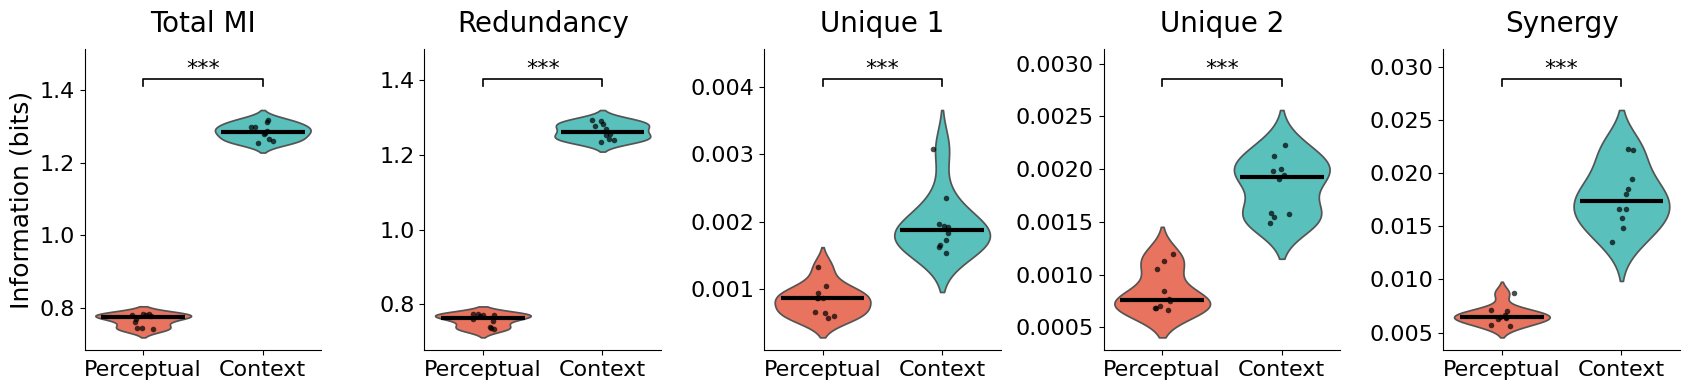

Saved decision-time violin figure to ../figures/pid_decision_time/decision_time_pid_violin.png


In [39]:
# output dir for the two decision-time figures
FIG_DEC_PID_DIR = "../figures/pid_decision_time"
os.makedirs(FIG_DEC_PID_DIR, exist_ok=True)

order = ['Perceptual', 'Context']     # perceptual ALWAYS left, context ALWAYS right
fig, axs = plt.subplots(1, 5, figsize=(17, 4))
for col, atom in enumerate(ATOMS):
    ctx = decision_atoms['context'][atom]        # (10,) context per-seed values
    per = decision_atoms['perceptual'][atom]     # (10,) perceptual per-seed values
    # tidy long-form frame: one row per (task, seed) value
    df = pd.DataFrame({
        'Value': np.concatenate([per, ctx]),
        'Task':  ['Perceptual'] * len(per) + ['Context'] * len(ctx)})
    ax = axs[col]
    # violins in the two task colors (hue=Task keeps seaborn 0.13+ happy; inner=None so
    # we draw our own, more visible median bar instead of the default dot/box)
    sns.violinplot(data=df, x='Task', y='Value', order=order, hue='Task', hue_order=order,
                   palette={'Context': COLOR_CONTEXT, 'Perceptual': COLOR_PERCEPTUAL},
                   legend=False, inner=None, ax=ax)
    # individual seed points on top
    sns.stripplot(data=df, x='Task', y='Value', order=order, ax=ax,
                  color='black', size=4, alpha=0.7)
    # bold horizontal cross-bar at each task's MEDIAN (replaces the usual mean dot);
    # x positions follow `order`: 0 = perceptual (left), 1 = context (right)
    for x_pos, vals in zip((0, 1), (per, ctx)):
        ax.hlines(np.median(vals), x_pos - 0.35, x_pos + 0.35, color='black', lw=3, zorder=5)
    # significance bracket -- ALWAYS drawn (L-shaped, NOT an error-bar |--|): the marker is
    # the global p_to_stars on this atom's Bonferroni-corrected p (total_mi uncorrected,
    # k=1; the 4 comparison atoms corrected, k=4), and is 'n.s.' when not significant.
    sig_label = p_to_stars(mwu_pvals_bonf[atom])
    ylim = ax.get_ylim(); span = ylim[1] - ylim[0]
    y_br = ylim[1] + 0.05 * span; leg = 0.03 * span
    ax.plot([0, 0, 1, 1], [y_br, y_br + leg, y_br + leg, y_br], lw=1.2, color='black')
    ax.text(0.5, y_br + leg, sig_label,
            ha='center', va='bottom', color='black', fontsize=FS_SIG_MARKER)
    ax.set_ylim(top=y_br + 5 * leg)                    # headroom (no clip)
    # subplot title = atom NAME (Fig-3 style); fonts inherit the global conventions
    ax.set_title(ATOM_NAMES[atom], pad=12)
    ax.set_ylabel('Information (bits)' if col == 0 else '')
    # y-axis label font size (global Fig-4 violin convention)
    ax.yaxis.label.set_size(FS_YLABEL_VIOLIN)
    ax.set_xlabel('')
    # x-axis tick label font size (global Fig-4/5 convention)
    ax.tick_params(axis='x', labelsize=FS_TICK)
plt.tight_layout()
fig.savefig(f"{FIG_DEC_PID_DIR}/decision_time_pid_violin.png", dpi=300)
plt.show()
print(f"Saved decision-time violin figure to {FIG_DEC_PID_DIR}/decision_time_pid_violin.png")

#### 4c. Decision-time PID bars (quick-read variant)
The same decision-time statistics as the violins, shown as grouped **mean +/- SD** bars:
for each of the 4 atoms a Perceptual (left) and a Context (right) bar (task colors), an SD
error bar, and the mean value printed above it (fontsize 12). A horizontal bracket with
the significance marker (global `p_to_stars` on the Bonferroni-corrected p) sits above each
atom's pair. Reuses the Fig-3 mean/SD and the 4a MWU p-values (nothing recomputed). Saved
to `figures/pid_decision_time/decision_time_pid_bars.png`.

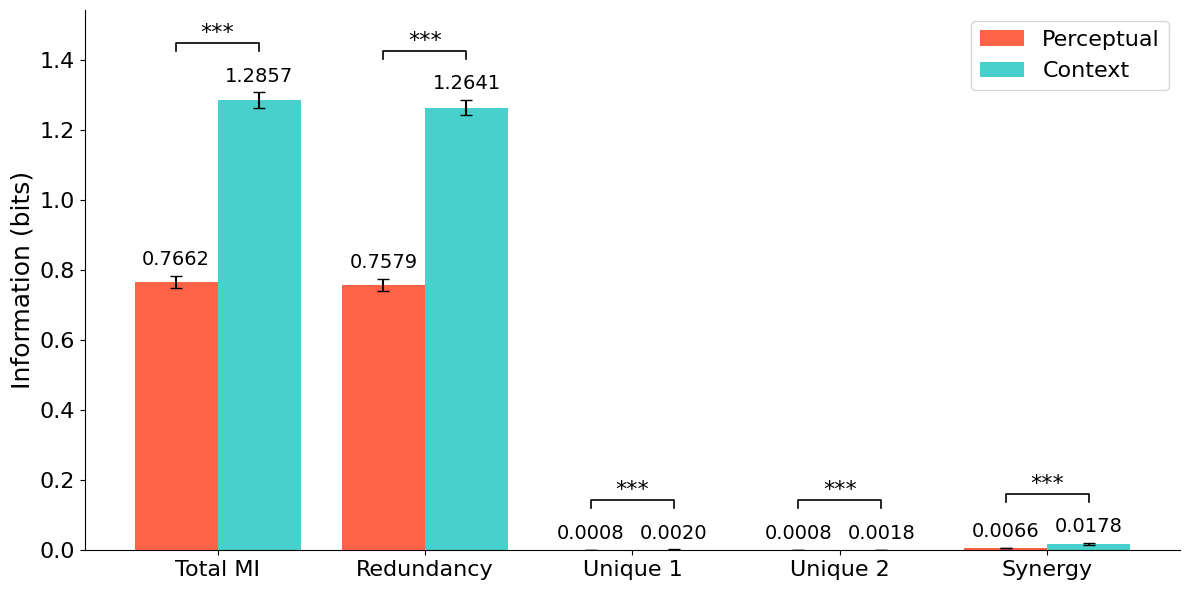

Saved decision-time bar figure to ../figures/pid_decision_time/decision_time_pid_bars.png


In [40]:
x    = np.arange(len(ATOMS))    # one group per atom (x tick), atom-ordered
wbar = 0.4                      # width of each of the two grouped bars

# Fig-3 across-seed mean/SD at DECISION_T (reused, NOT recomputed), atom-ordered.
ctx_means = np.array([mean_time_PID['context'][DECISION_T, j]    for j in range(len(ATOMS))])
ctx_sds   = np.array([sd_time_PID['context'][DECISION_T, j]      for j in range(len(ATOMS))])
per_means = np.array([mean_time_PID['perceptual'][DECISION_T, j] for j in range(len(ATOMS))])
per_sds   = np.array([sd_time_PID['perceptual'][DECISION_T, j]   for j in range(len(ATOMS))])

fig, ax = plt.subplots(figsize=(12, 6))
# grouped bars with SD error bars (perceptual ALWAYS left, context ALWAYS right)
ax.bar(x - wbar/2, per_means, wbar, yerr=per_sds, capsize=4,
       color=COLOR_PERCEPTUAL, label='Perceptual')
ax.bar(x + wbar/2, ctx_means, wbar, yerr=ctx_sds, capsize=4,
       color=COLOR_CONTEXT,    label='Context')

# vertical offsets scaled to the data so labels/brackets never clip
ymax_data = max((ctx_means + ctx_sds).max(), (per_means + per_sds).max())
voff = 0.015 * ymax_data        # gap between error-bar cap and the printed value
boff = 0.09  * ymax_data        # height of the significance bracket above the pair

# mean value printed just above each error bar (global bar-value font size)
for xb, m, s in (list(zip(x - wbar/2, per_means, per_sds)) +
                 list(zip(x + wbar/2, ctx_means, ctx_sds))):
    ax.text(xb, m + s + voff, f"{m:.4f}", ha='center', va='bottom', fontsize=FS_BAR_VALUE)

# per-atom significance bracket -- ALWAYS drawn over each pair: the marker is the global
# p_to_stars on this atom's Bonferroni-corrected p ('n.s.' when not significant).
for i, atom in enumerate(ATOMS):
    pair_top = max(ctx_means[i] + ctx_sds[i], per_means[i] + per_sds[i])
    y_br = pair_top + boff
    sig_label = p_to_stars(mwu_pvals_bonf[atom])
    ax.plot([x[i] - wbar/2, x[i] - wbar/2, x[i] + wbar/2, x[i] + wbar/2],
            [y_br, y_br + 0.2*boff, y_br + 0.2*boff, y_br], lw=1.2, color='black')
    ax.text(x[i], y_br + 0.2*boff, sig_label,
            ha='center', va='bottom', fontsize=FS_SIG_MARKER)

ax.set_ylim(top=ymax_data + 2*boff)         # headroom for values + bracket + star
ax.set_xticks(x); ax.set_xticklabels([ATOM_NAMES[a] for a in ATOMS])  # atom names, not keys
ax.set_ylabel('Information (bits)')
ax.tick_params(axis='x', labelsize=FS_TICK)   # x-axis tick font size (global convention)
ax.tick_params(axis='y', labelsize=FS_TICK)   # y-axis tick font size (global convention)
ax.legend(loc='upper right')
plt.tight_layout()
fig.savefig(f"{FIG_DEC_PID_DIR}/decision_time_pid_bars.png", dpi=300)
plt.show()
print(f"Saved decision-time bar figure to {FIG_DEC_PID_DIR}/decision_time_pid_bars.png")

## Figure 5: Normalized PID composition (compositional vs magnitude confound)
At `DECISION_T` Figure 4 showed context carries **more** total information and **more** of
every atom: a raw **magnitude** effect. The open question (Prediction 2) is whether the two
tasks also differ in **composition** (i.e., how that total is split into redundant / unique /
synergistic fractions) **independent** of magnitude. To separate the two we normalize each
atom by its seed's `total_mi` and, because the 50/50 bipartition makes the X1/X2 source
labels arbitrary and exchangeable, also form the **total unique** fraction
(`norm_unique = norm_unique1 + norm_unique2`). We then test with a **two-tier** framework,
each tier its own Bonferroni family: **Tier 1** primary (compositional, independent) = the
4 normalized fractions (`norm_unique1`, `norm_unique2`, `norm_redundancy`, `norm_synergy`,
k=4); **Tier 2** derived (deterministic sums of Tier-1 members) = `total_mi` in raw bits
(raw p reused from Fig 4a) and `norm_unique`, both corrected at k=2. All of this **reuses
the cached decision-time data** from cell 4a; no PID value is recomputed.

#### 5a. Normalized fractions & total unique: two-tier MWU
Reusing the cached `decision_atoms[task][atom]` (built in cell 4a, **not** rebuilt), turn
each atom into a **fraction of that seed's total MI** and form the **total unique** fraction
`norm_unique = norm_unique1 + norm_unique2` (the 50/50 bipartition makes the X1/X2 source
labels arbitrary and exchangeable, so the two unique terms are pooled). All five quantities
are dimensionless. Then run one two-sided Mann-Whitney U (context vs perceptual) per
quantity, organized into two tiers with **independent** Bonferroni families:
**Tier 1** primary (compositional, independent) = the 4 normalized fractions
`norm_unique1`, `norm_unique2`, `norm_redundancy`, `norm_synergy`
(family=`comparison_normalized`, k=4); **Tier 2** derived = `total_mi` in raw bits and
`norm_unique` (family=`magnitude_normalized`, k=2). `total_mi`'s raw p is **reused** from
Figure 4a (the MWU is not rerun) but is re-corrected at k=2 for this family. `total_mi` is
the deterministic sum of the four raw atoms and `norm_unique` the deterministic sum of two
Tier-1 fractions, so neither carries an independent hypothesis; rather than leaving them
uncorrected or folding them into Tier 1, both are grouped into their own **two-way
corrected** family. Each family
Bonferroni-corrects its **p-values** (never the threshold); significance follows the global
`p_to_stars` criteria on the corrected p. Each new test's stats are appended to the running
`stats_summary.csv` (`total_mi`'s row already exists). A per-tier summary is printed.
Nothing is recomputed.

In [41]:
# Per-task normalized fractions + total unique, one value per seed (elementwise over the
# 10 seeds). Reuses decision_atoms (built in cell 4a); NO PID is recomputed. Every quantity
# is DIMENSIONLESS (a fraction of total MI), so it isolates COMPOSITION from the raw
# MAGNITUDE already shown in Figure 4.
fraction_atoms = {}
for task in TASKS:
    tot = decision_atoms[task]['total_mi']                             # (10,) total MI (bits) per seed
    norm_unique1 = decision_atoms[task]['unique1'] / tot               # unique-1 fraction
    norm_unique2 = decision_atoms[task]['unique2'] / tot               # unique-2 fraction
    fraction_atoms[task] = {
        'norm_redundancy': decision_atoms[task]['redundancy'] / tot,   # redundant fraction
        'norm_unique1':    norm_unique1,
        'norm_unique2':    norm_unique2,
        'norm_synergy':    decision_atoms[task]['synergy']    / tot,   # synergistic fraction
        # total normalized unique info = norm_unique1 + norm_unique2. The 50/50 bipartition
        # makes the X1/X2 source labels arbitrary and exchangeable, so the two unique terms
        # are pooled into a single "total unique" fraction (a deterministic sum of two
        # Tier-1 members).
        'norm_unique':     norm_unique1 + norm_unique2,
    }

# Two tiers, each with its OWN independent Bonferroni family. Only the P-VALUES are
# corrected (x k, never the threshold); significance is decided by the GLOBAL p_to_stars
# rules on the corrected p:
#   Tier 1 (primary, compositional, independent): the 4 normalized fractions
#           (norm_unique1, norm_unique2, norm_redundancy, norm_synergy) -- each an
#           independent compositional hypothesis (k=4). family='comparison_normalized'.
#   Tier 2 (derived, deterministic sums of Tier-1 members): total_mi in raw bits and
#           norm_unique (= norm_unique1 + norm_unique2). total_mi is the deterministic sum
#           of the four raw atoms and norm_unique the deterministic sum of two Tier-1
#           fractions, so NEITHER carries an independent hypothesis -- rather than leaving
#           them uncorrected or folding them into Tier 1, both are grouped into their OWN
#           two-way corrected family (k=2). family='magnitude_normalized'. total_mi's RAW p
#           is REUSED from Figure 4a (mwu_pvals['total_mi']; the MWU is NOT rerun) but is
#           re-corrected at k=2 for THIS family. Its Fig-4a CSV row (family='magnitude',
#           k=1) is left untouched and NOT re-added here. Only norm_unique is a new test.
COMPARISON_NORM_BONFERRONI = 4     # Tier-1 family size (4 independent normalized fractions)
MAGNITUDE_NORM_BONFERRONI  = 2     # Tier-2 family size (total_mi + norm_unique)

# total_mi's Tier-2 corrected p: reuse its Fig-4a RAW p (MWU not rerun) but Bonferroni-
# correct it at k=2, so it is a full member of this two-way corrected family.
total_mi_pbonf_t2 = min(mwu_pvals['total_mi'] * MAGNITUDE_NORM_BONFERRONI, 1.0)

# (quantity, tier label, family, bonferroni_k). The 4 Tier-1 fractions first, then the new
# Tier-2 derived quantity norm_unique. total_mi (also Tier 2) is reused from Fig 4a and
# printed separately below, not re-tested here.
FIG5_TESTS = [
    ('norm_unique1',    'Tier 1 (primary)', 'comparison_normalized', COMPARISON_NORM_BONFERRONI),
    ('norm_unique2',    'Tier 1 (primary)', 'comparison_normalized', COMPARISON_NORM_BONFERRONI),
    ('norm_redundancy', 'Tier 1 (primary)', 'comparison_normalized', COMPARISON_NORM_BONFERRONI),
    ('norm_synergy',    'Tier 1 (primary)', 'comparison_normalized', COMPARISON_NORM_BONFERRONI),
    ('norm_unique',     'Tier 2 (derived)', 'magnitude_normalized',  MAGNITUDE_NORM_BONFERRONI),
]

# Drop the retired balance row if it lingers from an earlier (pre-update) run in the same
# kernel, so it is never written back to stats_summary.csv.
stats_summary_records.pop('mwu_decision_balance', None)

# One two-sided MWU per NEW quantity (context vs perceptual, n=10 vs 10). Distinct dicts
# (prefix f*) so NO Figure-4 stats variable is ever reused/overwritten.
fmwu_ustats     = {}   # name -> U statistic
fmwu_pvals      = {}   # name -> raw p-value
fmwu_pvals_bonf = {}   # name -> Bonferroni-corrected p (drives the significance markers)
for name, tier, family, bonf_k in FIG5_TESTS:
    ctx_frac = fraction_atoms['context'][name]        # (10,) context per-seed values
    per_frac = fraction_atoms['perceptual'][name]     # (10,) perceptual per-seed values
    u_frac, p_frac = stats.mannwhitneyu(ctx_frac, per_frac, alternative='two-sided')
    p_frac_bonf = min(p_frac * bonf_k, 1.0)           # corrected p within this tier (capped at 1.0)
    fmwu_ustats[name]     = float(u_frac)
    fmwu_pvals[name]      = float(p_frac)
    fmwu_pvals_bonf[name] = float(p_frac_bonf)
    # per-task mean/SD of the quantity across the 10 seeds (ddof=1)
    ctx_mean_f, ctx_sd_f = float(ctx_frac.mean()), float(ctx_frac.std(ddof=1))
    per_mean_f, per_sd_f = float(per_frac.mean()), float(per_frac.std(ddof=1))
    # unique key per quantity -> row overwritten on re-run, never duplicated/reused
    stats_summary_records[f"mwu_decision_{name}"] = {
        'test': 'Mann-Whitney U (context vs perceptual) @ DECISION_T',
        'task': 'context_vs_perceptual',
        'atom': name,
        'family': family,
        'n': N_SEEDS,
        'statistic': float(u_frac),
        'p_value': float(p_frac),
        'p_value_bonferroni': float(p_frac_bonf),
        'bonferroni_factor': bonf_k,
        'context_mean': ctx_mean_f,    'context_sd': ctx_sd_f,
        'perceptual_mean': per_mean_f, 'perceptual_sd': per_sd_f,
        'significant': p_to_stars(p_frac_bonf) != 'n.s.',
    }

# ---- printed summary, grouped by tier (family / k labelled per tier) ----
print("Figure 5 -- two-tier decision-time MWU (context vs perceptual), n=10 vs 10\n")
print("Tier 1 (primary/compositional) -- family='comparison_normalized' k=4")
for _nm in ['norm_unique1', 'norm_unique2', 'norm_redundancy', 'norm_synergy']:
    print(f"  {_nm:16s} U={fmwu_ustats[_nm]:5.1f}  p={fmwu_pvals[_nm]:.4g}  "
          f"p_bonf={fmwu_pvals_bonf[_nm]:.4g}  {p_to_stars(fmwu_pvals_bonf[_nm]):>4s}  "
          f"(ctx {fraction_atoms['context'][_nm].mean():.4f} | per {fraction_atoms['perceptual'][_nm].mean():.4f})")

print("\nTier 2 (derived, deterministic sums) -- family='magnitude_normalized' k=2")
# norm_unique: the NEW k=2 derived test
_nm = 'norm_unique'
print(f"  {_nm:16s} U={fmwu_ustats[_nm]:5.1f}  p={fmwu_pvals[_nm]:.4g}  "
      f"p_bonf={fmwu_pvals_bonf[_nm]:.4g}  {p_to_stars(fmwu_pvals_bonf[_nm]):>4s}  "
      f"(ctx {fraction_atoms['context'][_nm].mean():.4f} | per {fraction_atoms['perceptual'][_nm].mean():.4f})")
# total_mi: raw bits, RAW p reused from Figure 4a (MWU not rerun) but re-corrected at k=2;
# its Fig-4a CSV row (k=1 magnitude) is left untouched and not re-added here.
print(f"  {'total_mi':16s} U={mwu_ustats['total_mi']:5.1f}  p={mwu_pvals['total_mi']:.4g}  "
      f"p_bonf={total_mi_pbonf_t2:.4g}  {p_to_stars(total_mi_pbonf_t2):>4s}  "
      f"(ctx {mean_time_PID['context'][DECISION_T,0]:.4f} | per {mean_time_PID['perceptual'][DECISION_T,0]:.4f} bits)  [raw p reused from Fig 4a, k=2]")

# ---- re-write the running stats CSV so the new Figure-5 rows are persisted (same
#      union-of-columns pattern as cell 4a; the total_mi row already exists from cell 4a) ----
_base_cols = ['test', 'task', 'atom', 'n', 'statistic', 'p_value',
              'bonferroni_factor', 'pass_normality']
_extra = sorted({k for r in stats_summary_records.values() for k in r} - set(_base_cols))
csv_path = f"{STATS_OUT_DIR}/stats_summary.csv"
with open(csv_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=_base_cols + _extra)
    writer.writeheader()
    for key in sorted(stats_summary_records):            # deterministic row order
        writer.writerow(stats_summary_records[key])
print(f"\nWrote {len(stats_summary_records)} stat rows to {csv_path}")

Figure 5 -- two-tier decision-time MWU (context vs perceptual), n=10 vs 10

Tier 1 (primary/compositional) -- family='comparison_normalized' k=4
  norm_unique1     U= 88.0  p=0.004586  p_bonf=0.01835     *  (ctx 0.0015 | per 0.0011)
  norm_unique2     U= 85.0  p=0.009108  p_bonf=0.03643     *  (ctx 0.0014 | per 0.0011)
  norm_redundancy  U=  1.0  p=0.0002461  p_bonf=0.0009845   ***  (ctx 0.9832 | per 0.9891)
  norm_synergy     U= 99.0  p=0.0002461  p_bonf=0.0009845   ***  (ctx 0.0138 | per 0.0087)

Tier 2 (derived, deterministic sums) -- family='magnitude_normalized' k=2
  norm_unique      U= 88.0  p=0.004586  p_bonf=0.009173    **  (ctx 0.0030 | per 0.0022)
  total_mi         U=100.0  p=0.0001827  p_bonf=0.0003653   ***  (ctx 1.2857 | per 0.7662 bits)  [raw p reused from Fig 4a, k=2]

Wrote 22 stat rows to ../figures/stats_summary.csv


#### 5b. Normalized decision-time PID violins (2x3 panels)
The six quantities shown with the same visual grammar as Fig 4b, laid out as a **2 rows x 3 columns**
grid. Top row: `total_mi` (raw bits), `unique1`, `unique2` (normalized). Bottom row:
`redundancy`, `synergy` (normalized), and the **total unique** fraction (`norm_unique`).
Each panel uses the **correct tier's** Bonferroni-corrected p / alpha for its bracket
(`total_mi` and `norm_unique` -> Tier 2; the four normalized fractions -> Tier 1) and its
own y-label (bits vs fraction). Saved to
`figures/norm_pid_decision_time/decision_time_pid_norm_violin.png`.

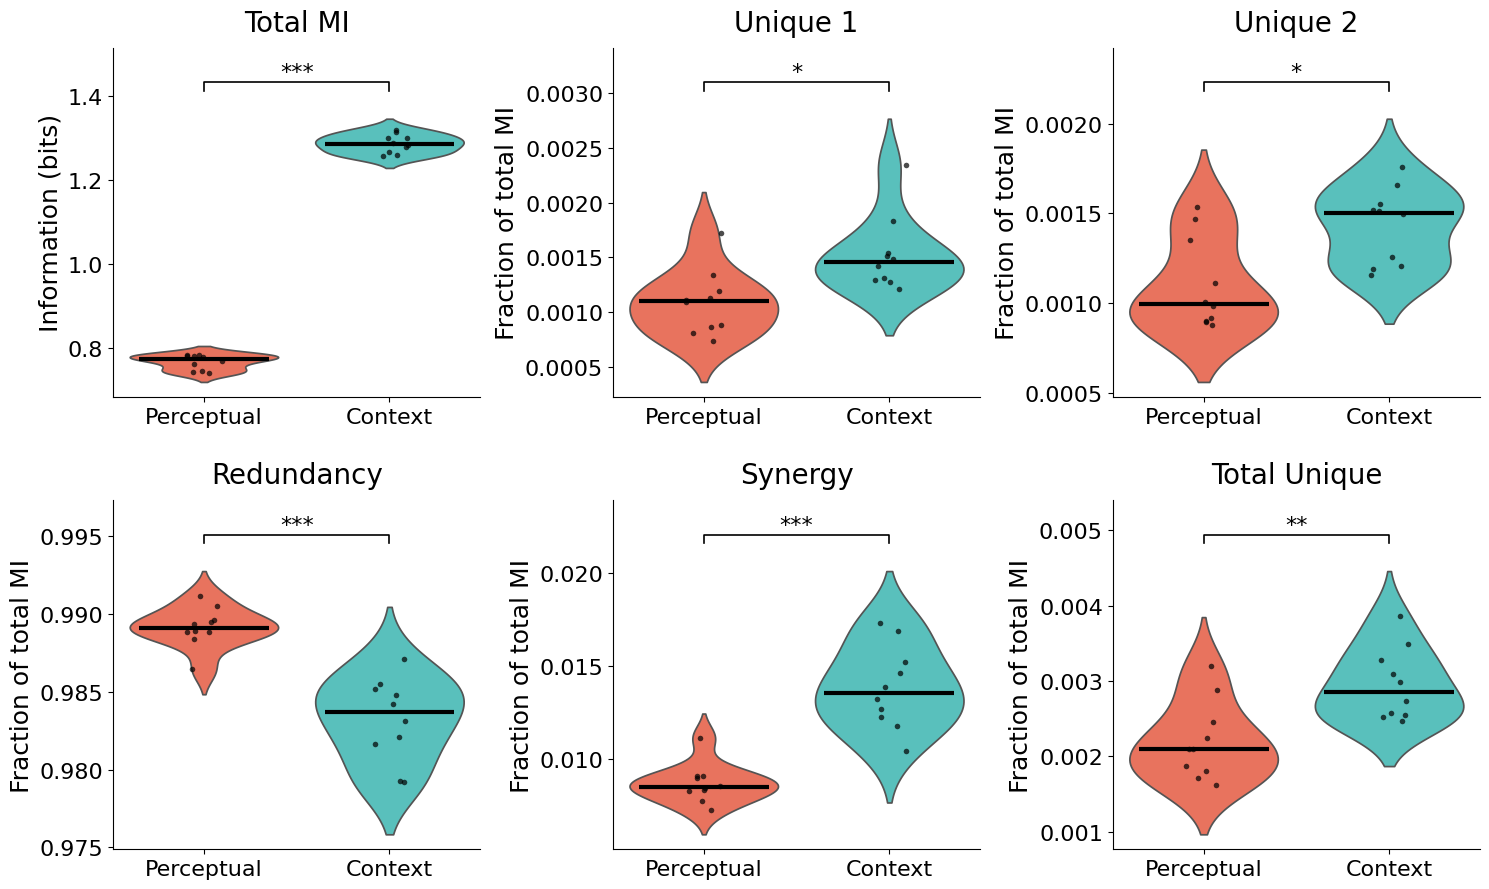

Saved normalized decision-time violin figure to ../figures/norm_pid_decision_time/decision_time_pid_norm_violin.png


In [42]:
# output dir for the two normalized decision-time figures
FIG_DEC_NORM_DIR = "../figures/norm_pid_decision_time"
os.makedirs(FIG_DEC_NORM_DIR, exist_ok=True)

# 2x3 panel layout shared by 5b (violins) and 5c (bars): (row, col), quantity key,
# subplot title, y-axis label. Top row = Total MI (bits) + the two unique fractions;
# bottom row = redundancy & synergy fractions + the total unique fraction. Units differ
# per panel, hence the per-panel y-labels.
FIG5_PANELS = [
    ((0, 0), 'total_mi',        'Total MI',     'Information (bits)'),
    ((0, 1), 'norm_unique1',    'Unique 1',     'Fraction of total MI'),
    ((0, 2), 'norm_unique2',    'Unique 2',     'Fraction of total MI'),
    ((1, 0), 'norm_redundancy', 'Redundancy',   'Fraction of total MI'),
    ((1, 1), 'norm_synergy',    'Synergy',      'Fraction of total MI'),
    ((1, 2), 'norm_unique',     'Total Unique', 'Fraction of total MI'),
]

def fig5_panel_data(name):
    """Return (perceptual_vals, context_vals, p_bonf) for a Fig-5 panel, picking the data
    source and the CORRECT tier's Bonferroni-corrected p:
      total_mi    -> Tier 2 (raw bits, Fig-4a raw p re-corrected at k=2),
      norm_unique -> Tier 2 (derived total unique, Bonferroni k=2),
      the four normalized fractions -> Tier 1 (Bonferroni k=4)."""
    if name == 'total_mi':                       # Tier 2: raw bits, Fig-4a raw p, k=2
        return (decision_atoms['perceptual']['total_mi'],
                decision_atoms['context']['total_mi'],
                total_mi_pbonf_t2)
    per_v = fraction_atoms['perceptual'][name]   # normalized fractions / total unique (Fig 5a)
    ctx_v = fraction_atoms['context'][name]
    return per_v, ctx_v, fmwu_pvals_bonf[name]   # Tier 1 (k=4) or Tier 2 norm_unique (k=2)

# Same visual grammar as Fig 4b (perceptual left / context right, task colors, inner=None
# with our own bold median cross-bar, seed points overlaid, significance bracket ALWAYS
# drawn) but arranged as a 2x3 grid over the six quantities.
fig, axs = plt.subplots(2, 3, figsize=(15, 9))
for (r, c), name, title, ylab in FIG5_PANELS:
    per, ctx, p_bonf = fig5_panel_data(name)   # correct data + tier corrected p per panel
    ax = axs[r, c]
    # tidy long-form frame: perceptual rows first so `order`/colors match Fig 4b
    df = pd.DataFrame({
        'Value': np.concatenate([per, ctx]),
        'Task':  ['Perceptual'] * len(per) + ['Context'] * len(ctx)})
    # violins in task colors (inner=None -> we draw our own, more visible median bar)
    sns.violinplot(data=df, x='Task', y='Value', order=order, hue='Task', hue_order=order,
                   palette={'Context': COLOR_CONTEXT, 'Perceptual': COLOR_PERCEPTUAL},
                   legend=False, inner=None, ax=ax)
    # individual seed points on top
    sns.stripplot(data=df, x='Task', y='Value', order=order, ax=ax,
                  color='black', size=4, alpha=0.7)
    # bold horizontal cross-bar at each task's MEDIAN (0 = perceptual left, 1 = context right)
    for x_pos, vals in zip((0, 1), (per, ctx)):
        ax.hlines(np.median(vals), x_pos - 0.35, x_pos + 0.35, color='black', lw=3, zorder=5)
    # L-shaped significance bracket -- ALWAYS drawn: the marker is the global p_to_stars on
    # this panel's Bonferroni-corrected p ('n.s.' when not significant).
    sig_label = p_to_stars(p_bonf)
    ylim = ax.get_ylim(); span = ylim[1] - ylim[0]
    y_br = ylim[1] + 0.05 * span; leg = 0.03 * span
    ax.plot([0, 0, 1, 1], [y_br, y_br + leg, y_br + leg, y_br], lw=1.2, color='black')
    ax.text(0.5, y_br + leg, sig_label, ha='center', va='bottom', fontsize=FS_SIG_MARKER)
    ax.set_ylim(top=y_br + 5 * leg)               # headroom so bracket is not clipped
    ax.set_title(title, pad=12)                       # per-panel atom title
    ax.set_ylabel(ylab); ax.yaxis.label.set_size(FS_YLABEL_GRID)  # per-panel units (bits / fraction)
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=FS_TICK)
plt.tight_layout(h_pad=2.5)                           # extra row gap so titles clear the tick labels
fig.savefig(f"{FIG_DEC_NORM_DIR}/decision_time_pid_norm_violin.png", dpi=300)
plt.show()
print(f"Saved normalized decision-time violin figure to {FIG_DEC_NORM_DIR}/decision_time_pid_norm_violin.png")

#### 5c. Normalized decision-time PID bars
The same six quantities as 5b as a quick-read **mean +/- SD** bar variant. Because the
panels mix incompatible units (bits, fractions), each panel is its **own** subplot with its **own**
y-limits: an SD error bar, the mean printed above/below the bar, and a significance bracket from the **correct tier**
(`total_mi` and `norm_unique` -> Tier 2; the four normalized fractions -> Tier 1). Per-panel axis
labels/titles match 5b. Reuses the cached decision-time values (nothing recomputed). Saved
to `figures/norm_pid_decision_time/decision_time_pid_norm_bars.png`.

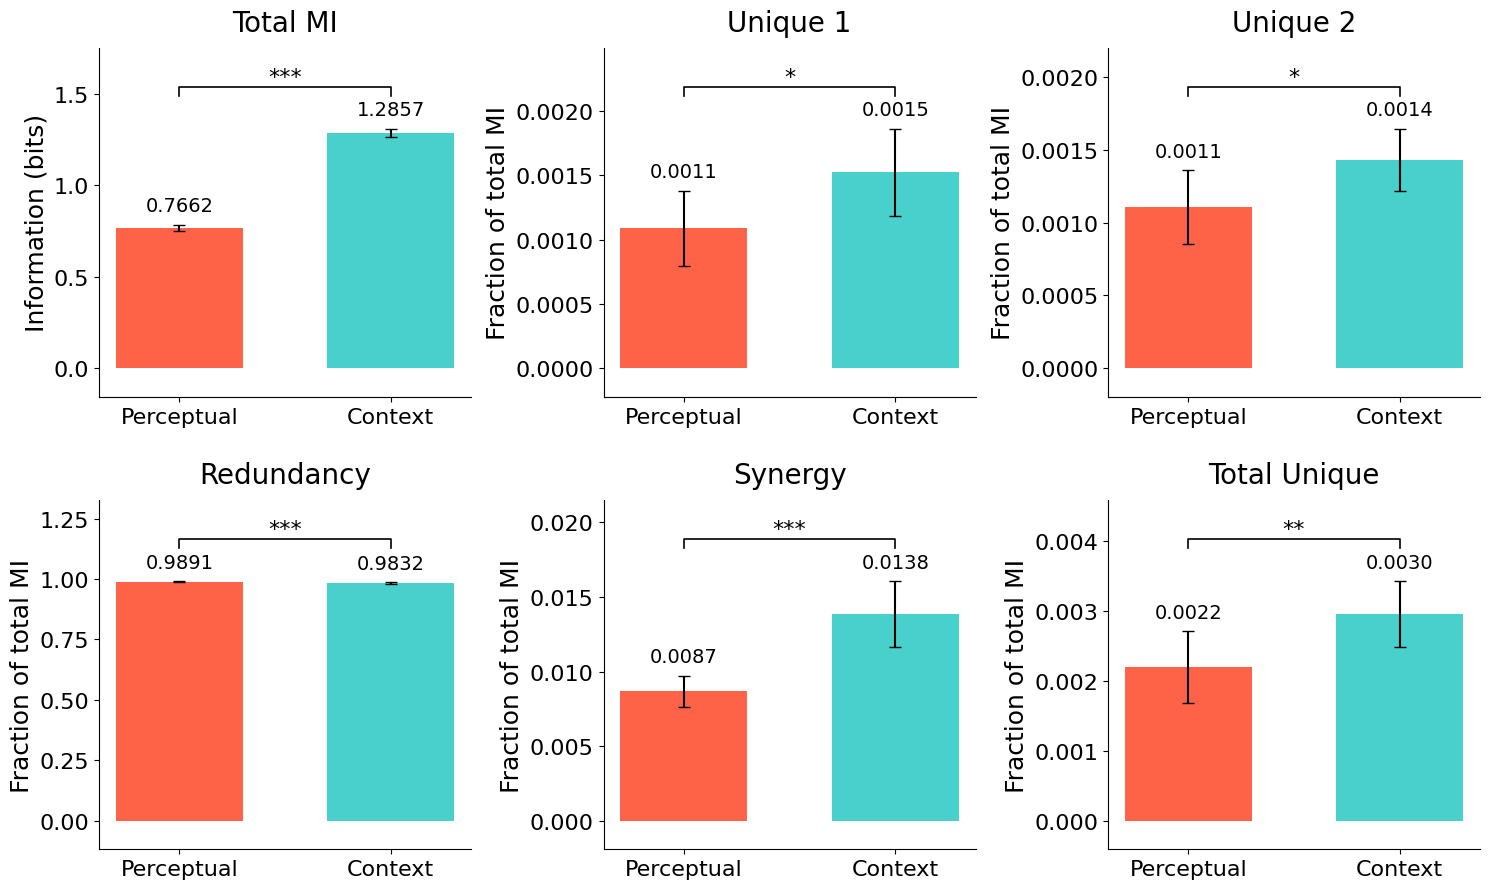

Saved normalized decision-time bar figure to ../figures/norm_pid_decision_time/decision_time_pid_norm_bars.png


In [43]:
# Same 2x3 panels as 5b, but as an INDEPENDENT-axis bar grid: the atoms mix units (bits
# vs fractions), so a single shared y-axis (as in Fig 4c) is meaningless here. Each panel
# gets its own ax, its own y-limits, a Perceptual (left) and Context (right) mean +/- SD
# bar, the printed mean, and its tier's significance bracket. Nothing recomputed: per-task
# mean/SD are taken across the 10 cached per-seed values.
fig, axs = plt.subplots(2, 3, figsize=(15, 9))
for (r, c), name, title, ylab in FIG5_PANELS:
    per, ctx, p_bonf = fig5_panel_data(name)   # correct data + tier corrected p per panel
    ax = axs[r, c]
    # per-task mean/SD across the 10 seeds (ddof=1); total_mi in bits, the rest fractions
    per_m, per_s = per.mean(), per.std(ddof=1)
    ctx_m, ctx_s = ctx.mean(), ctx.std(ddof=1)
    means = np.array([per_m, ctx_m]); sds = np.array([per_s, ctx_s])
    # grouped bars: perceptual ALWAYS left (x=0), context ALWAYS right (x=1), task colors
    ax.bar([0, 1], means, 0.6, yerr=sds, capsize=4, color=[COLOR_PERCEPTUAL, COLOR_CONTEXT])
    # data extent incl. error caps and the 0 baseline -> per-panel y-limits & offsets
    # (include the 0 baseline so each bar reads against zero)
    highs = means + sds; lows = means - sds
    dmax = max(highs.max(), 0.0); dmin = min(lows.min(), 0.0)
    span = (dmax - dmin) or 1.0
    voff = 0.04 * span; boff = 0.14 * span
    # mean printed just beyond each error cap (above positive bars, below negative bars)
    for xb, m, s in zip((0, 1), means, sds):
        if m >= 0:
            ax.text(xb, m + s + voff, f"{m:.4f}", ha='center', va='bottom', fontsize=FS_BAR_VALUE)
        else:
            ax.text(xb, m - s - voff, f"{m:.4f}", ha='center', va='top', fontsize=FS_BAR_VALUE)
    # significance bracket over the pair -- ALWAYS drawn: the marker is the global p_to_stars
    # on this panel's Bonferroni-corrected p ('n.s.' when not significant).
    sig_label = p_to_stars(p_bonf)
    y_br = dmax + boff
    ax.plot([0, 0, 1, 1], [y_br, y_br + 0.25*boff, y_br + 0.25*boff, y_br], lw=1.2, color='black')
    ax.text(0.5, y_br + 0.25*boff, sig_label, ha='center', va='bottom', fontsize=FS_SIG_MARKER)
    # independent y-limits sized to THIS panel (headroom for labels + bracket + star)
    ax.set_ylim(dmin - 3*voff, dmax + boff + 5*voff)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Perceptual', 'Context'])
    ax.set_title(title, pad=12)               # per-panel atom title (as in 5b)
    ax.set_ylabel(ylab); ax.yaxis.label.set_size(FS_YLABEL_GRID)   # per-panel units (bits / fraction)
    ax.tick_params(axis='x', labelsize=FS_TICK)
plt.tight_layout(h_pad=2.5)                   # extra row gap so titles clear the tick labels
fig.savefig(f"{FIG_DEC_NORM_DIR}/decision_time_pid_norm_bars.png", dpi=300)
plt.show()
print(f"Saved normalized decision-time bar figure to {FIG_DEC_NORM_DIR}/decision_time_pid_norm_bars.png")